# Tasks 4.3 and 4.9

## Task 4.3
**4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for Vic B/Austria/1359417/2021 at Day 28

## Task 4.9
**4.9 Predict antibody durability - Vic B/Austria/1359417/2021 (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate + **Day 28**
* Assay: HAI / Measure: Post-vac HAI / Metric: Spearman correlation
* Full description: Post-vac HAI of the B Victoria vaccine strain at Day 365

---

## Design notes

**y-values:** log2-transformed. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Metrics (RMSE, MAE, Spearman) are all in log2 space; CSVs use `np.exp2` to output raw titer scale values.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
STRAIN = 'Vic B/Austria/1359417/2021'
TARGET_COL_4_3 = f'HAI_{STRAIN}_d28'  # task 4.3
TARGET_COL_4_9 = f'HAI_{STRAIN}_d365'  # task 4.9

In [2]:
import numpy as np
import pandas as pd

from model_utils import evaluate, predict_challenge, vaccine_cols

In [3]:
DATA_PATH = 'cleaned_data'
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

# Data is pre-cleaned: one row per participant, HAI columns as HAI_{strain}_d{timepoint},
# participant columns as PART_{field}.
data = train_hai.merge(train_participants, on='participant_id', how='inner')
part_cols = [c for c in data.columns if c.startswith('PART_')]
print(f'Merged shape: {data.shape}')

# Challenge set: unseen participants we generate final submission predictions for.
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Merged shape: (3757, 201)
Challenge shape: (40, 23)


---

## Task 4.3 — Single strain HAI at Day 28

Samples: 920   Features: 4
Spearman (5-fold CV): 0.671  (p-value: 2.201e-121)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.5617     2.4389   1.1617     0.6710


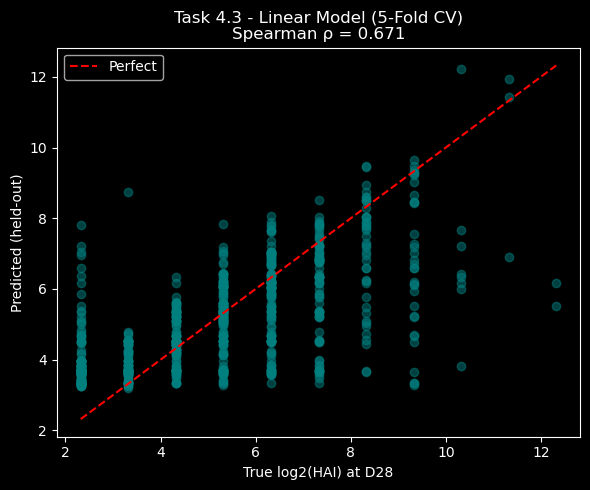

In [4]:
# Features: Day 0 strain HAI + demographics (no future data)
feature_cols = vaccine_cols(data, [STRAIN], '0') + part_cols

y_vals = data[TARGET_COL_4_3].copy()
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

y_pred_cv, model = evaluate(X, y_vals, 'Task 4.3', y_axis_label='True log2(HAI) at D28')

In [5]:
# Apply the already-trained model to the challenge set (no refitting).
y_pred_challenge = predict_challenge(model, challenge_data, feature_cols)

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.3': np.exp2(y_pred_challenge),  # reverse log2 -> raw titer
})
results.to_csv('submission/task_4_3.csv', index=False)
results

,Participant_ID,Task_4.3
0,2024_UGA.ID_077,46.815201
1,2024_UGA.ID_086,65.684473
2,2024_UGA.ID_128,22.823225
3,2024_UGA.ID_170,26.410192
4,2024_UGA.ID_179,82.985505
5,2024_UGA.ID_215,40.545315
6,2024_UGA.ID_219,57.449192
7,2024_UGA.ID_275,47.225891
8,2024_UGA.ID_295,827.429580
9,2024_UGA.ID_296,37.257882


---

## Task 4.9 — Single strain HAI at Day 365 (durability)

Samples: 492   Features: 5
Spearman (5-fold CV): 0.755  (p-value: 6.383e-92)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.0499     1.1023   0.7886     0.7552


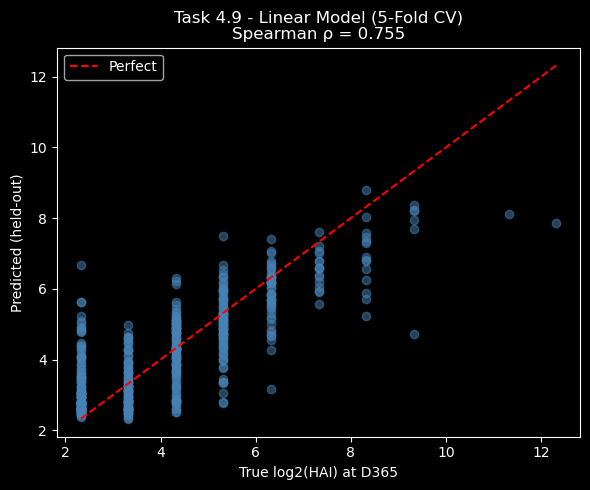

In [6]:
# Features: Day 0 + Day 28 strain HAI + demographics (d28 allowed for durability task)
feature_cols = (
        vaccine_cols(data, [STRAIN], '0')
        + vaccine_cols(data, [STRAIN], '28')
        + part_cols
)

y_vals = data[TARGET_COL_4_9].copy()
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

y_pred_cv, model = evaluate(X, y_vals, 'Task 4.9', plot_color='steelblue',
                            y_axis_label='True log2(HAI) at D365')

In [7]:
# Apply the already-trained model to the challenge set (no refitting).
y_pred_challenge = predict_challenge(model, challenge_data, feature_cols)

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.9': np.exp2(y_pred_challenge),
})
results.to_csv('submission/task_4_9.csv', index=False)
results

,Participant_ID,Task_4.9
0,2024_UGA.ID_077,21.479379
1,2024_UGA.ID_086,31.919566
2,2024_UGA.ID_128,14.369499
3,2024_UGA.ID_170,16.921742
4,2024_UGA.ID_179,27.264552
5,2024_UGA.ID_215,18.382789
6,2024_UGA.ID_219,28.295393
7,2024_UGA.ID_275,22.161248
8,2024_UGA.ID_295,73.311824
9,2024_UGA.ID_296,25.642664
